# Практическое задание № 1. Классификация


**Работу выполнила:**

Охрименко Ева Дмитриевна 409290

# Распознавание активности человека на основе данных с мобильных сенсоров

Необходимо по данным с мобильных сенсоров при помощи прикладных алгоритмов машинного обучения предсказать активность человека по шести классам движений:
* Движется по прямой
* Движется вверх (например, движение по лестнице вверх)
* Движется вниз (например, движение по лестнице вниз)
* Сидит
* Стоит
* Лежит

## Сведения о наборе данных
Набор данных содержит записи датчиков со сматфонов (акселерометр и гироскоп с частотой дискретизации 50 Гц) от 30 участников, выполняющих следующие действия: ходьба, ходьба по лестнице, ходьба по лестнице, сидение, стояние и лежание. Данные были предварительно обработаны при помощи фильтров шума. Набор данных представлен Хорхе Л. Рейес-Ортисом.

Признаки были извлечены из 3-х осевых необработанных сигналов акселерометра и гироскопа tAcc-XYZ и tGyro-XYZ. Эти сигналы были сняты с постоянной частотой 50 Гц. Затем были отфильтрованны с помощью медианного фильтра и низкочастотного фильтра Баттерворта 3-го порядка с частотой 20 Гц для удаления шумов. Аналогичным образом сигнал ускорения был разделен на сигналы ускорения тела и гравитации (`tBodyAcc-XYZ` и `tGravityAcc-XYZ`) с помощью другого низкочастотного фильтра Баттерворта с угловой частотой 0,3 Гц. Линейное ускорение тела и угловая скорость были использованы для получения сигналов "рывка" — (`tBodyAccJerk-XYZ` и `tBodyGyroJerk-XYZ`). Также величина этих трехмерных сигналов была расчитана с использованием евклидовой нормы — (`tBodyAccMag`, `tGravityAccMag`, `tBodyAccJerkMag`, `tBodyGyroMag`, `tBodyGyroJerkMag`).

Наконец, к некоторым из этих сигналов было применено быстрое преобразование Фурье (БПФ), в результате чего получились `fBodyAcc-XYZ`, `fBodyAccJerk-XYZ`, `fBodyGyro-XYZ`, `fBodyAccJerkMag`, `fBodyGyroMag`, `fBodyGyroJerkMag`. (Обратите внимание на "f" для обозначения сигналов в частотной области).

Набор переменных, которые были оценены по этим сигналам, следующий:
* mean(): Среднее значение
* std(): Стандартное отклонение
* mad(): Среднее абсолютное отклонение
* max(): Наибольшее значение в массиве
* min(): Наименьшее значение в массиве
* sma(): Область величины сигнала
* energy(): Мера энергии. Сумма квадратов, деленная на количество значений.
* iqr(): Интерквартильный размах
* entropy(): Энтропия сигнала
* arCoeff(): Коэффициенты авторегрессии с порядком Burg, равным 4
* correlation(): коэффициент корреляции между двумя сигналами
* maxInds(): индекс частотной составляющей с наибольшей величиной
* meanFreq(): средневзвешенное значение частотных компонент для получения средней частоты
* skewness(): перекос сигнала в частотной области
* kurtosis(): эксцесс сигнала в частотной области
* bandsEnergy(): Энергия частотного интервала в пределах 64 бинов БПФ каждого окна.
* angle(): Угол между векторами.
## Импорт библиотек
Первым делом импортируем необходимые библиотеки для работы с данными:

In [1]:
import pandas as pd

## Считываем набор данных

В прикладных задачах машинного обучения очень важен процесс извлечения признаков (feature extraction), в ходе которого данные интерпретируются в информативные признаки. Также этот процесс может называться проектирование признаков (feature engineering), это весьма трудоемкая и творческая задача. В рамках работы мы опустим эту часть и воспользуемся предобработанными данными.

Теперь, загрузим полный набор данных и сохранить его под следующими четырьмя переменными:

* `train_X`: признаки, используемые для обучения модели
* `train_y`: метки, используемые для обучения модели
* `test_X`: признаки, используемые для проверки модели
* `test_y`: метки, используемые для проверки модели

In [2]:
# noinspection PyUnresolvedReferences,PyTypeChecker
def load_dataset(label_dict):
    train_df = pd.read_csv('train.csv')
    test_df = pd.read_csv('test.csv')

    train_X = train_df.iloc[:, :-2].values
    train_y = train_df['Activity'].map(label_dict).values

    test_X = test_df.iloc[:, :-2].values
    test_y = test_df['Activity'].map(label_dict).values

    return train_X, train_y, test_X, test_y

label_dict = {
    'WALKING':0,
    'WALKING_UPSTAIRS':1,
    'WALKING_DOWNSTAIRS':2,
    'SITTING':3,
    'STANDING':4,
    'LAYING':5
}

train_X, train_y, test_X, test_y = load_dataset(label_dict)

## Выбор модели

Импортируйте выбранную вами модель из библиотеки `sklearn` и инициализируйте её в объект `model`:

Также необходимо выбрать **несколько** моделей ML для сравнения полученных результатов.

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Random Forest depth 5': RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42),
    'SVM': SVC(kernel='rbf'),
    'SVM rbf (C=1)': SVC(kernel='rbf', C=1, gamma='scale'),
    'SVM rbf (C=10)': SVC(kernel='rbf', C=10, gamma='scale'),
}

Опишите вашу мотивацию по выбору модели. Какие гиперпараметры есть у выбранной вами модели? За что они отвечают? На что влияют?

- Logistic Regression - быстрая базовая модель.  Гиперпараметры:

1. C - Сила регуляризации
2. penalty - Тип регуляризации
3. max_iter - Макс. итераций для сходимости

- Random Forest - устойчиывая к шуму модель. Гиперпараметры:
1. n_estimators - Количество деревьев (каждый оьект прогоняется через эти деревья)
2. max_depth - Глубина деревьев

RandomForestClassifier — это ансамбль решающих деревьев.
Каждое дерево обучается на случайной подвыборке объектов и случайном подмножестве признаков, затем деревья голосуют за итоговый класс.

random_state — это фиксатор случайности.
Он задаёт стартовое значение генератора случайных чисел, чтобы:

каждый запуск модели давал одинаковые результаты, можно было воспроизводимо сравнивать модели с разными параметрами.

random_state не влияет на качество, он влияет только на повторяемость эксперимента.
- SVM. Гиперпараметры:
1. C - Штраф за ошибки.
2. kernel - Ядро ('linear', 'rbf', 'poly').
3. gamma - Влияние одного примера.
Большая gamma = граница «круто загибается» возле точек.
Маленькая gamma = граница сглажена и почти прямая.

## Обучение модели

Обучите модель, используя признаки из обучающего набора (`train_X`) и метки в качестве базовой истины (`train_y`).

In [4]:
for name, model in models.items():
    model.fit(train_X, train_y)
    predictions = model.predict(test_X)
    print(f"Model: {name}")
    print(f"Accuracy: {accuracy_score(test_y, predictions):.4f}")
    print(classification_report(test_y, predictions, target_names=label_dict.keys()))
    print("*" * 60)



Model: Logistic Regression
Accuracy: 0.9610
                    precision    recall  f1-score   support

           WALKING       0.94      0.99      0.97       496
  WALKING_UPSTAIRS       0.97      0.94      0.96       471
WALKING_DOWNSTAIRS       0.99      0.96      0.98       420
           SITTING       0.98      0.88      0.92       491
          STANDING       0.90      0.98      0.94       532
            LAYING       1.00      1.00      1.00       537

          accuracy                           0.96      2947
         macro avg       0.96      0.96      0.96      2947
      weighted avg       0.96      0.96      0.96      2947

************************************************************
Model: Random Forest
Accuracy: 0.9257
                    precision    recall  f1-score   support

           WALKING       0.89      0.97      0.93       496
  WALKING_UPSTAIRS       0.88      0.89      0.89       471
WALKING_DOWNSTAIRS       0.97      0.86      0.91       420
           SI

TypeError: len() takes exactly one argument (0 given)

In [6]:
len(train_X)

7352

## Оценка модели
Используйте обученную модель для прогнозирования активности движения, используя признаки из тестового набора (`test_X`). Прогнозы сохраните в списке `yhat`.

Logistic Regression accuracy: 0.9600
Random Forest accuracy: 0.9257
Random Forest depth 5 accuracy: 0.8911
SVM accuracy: 0.9505
SVM rbf (C=1) accuracy: 0.9505
SVM rbf (C=10) accuracy: 0.9620


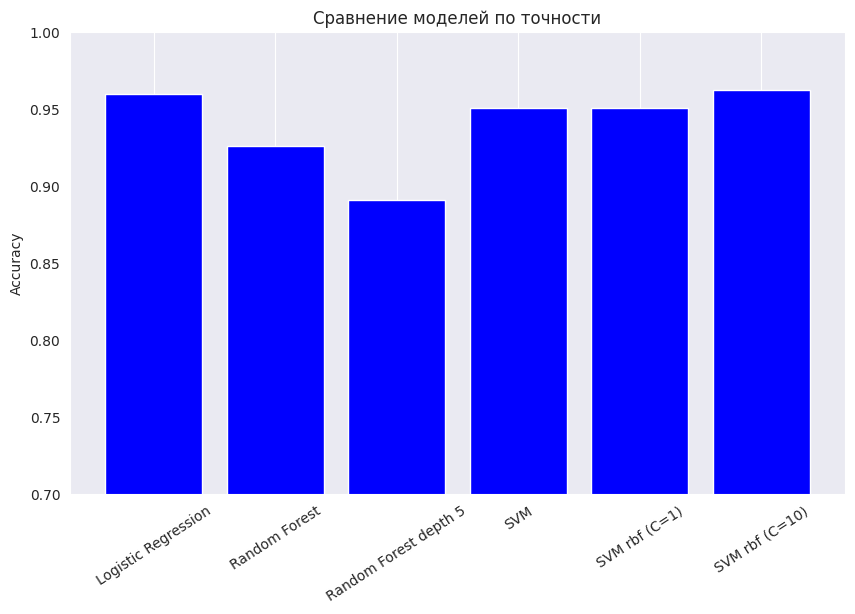

In [ ]:
#Результаты сравнения
import matplotlib.pyplot as plt

results = {}

for name, model in models.items():
    model.fit(train_X, train_y)
    yhat = model.predict(test_X)
    acc = accuracy_score(test_y, yhat)
    results[name] = acc
    print(f"{name} accuracy: {acc:.4f}")

plt.figure(figsize=(10,6))
plt.bar(results.keys(), results.values(), color='blue')
plt.ylim([0.7, 1])
plt.ylabel('Accuracy')
plt.title('Сравнение моделей по точности')
plt.xticks(rotation=33)
plt.grid(axis='y')
plt.show()

## Задание


Выведите отчет о классификации, сравнив предсказания (`yhat`) с базовой истиной (`test_y`).

В чем разница между показателями `precision` и `recall`? Что такое показатель `F1`?

- Precision измеряет надежность положительных прогнозов модели, показывая долю верных срабатываний среди всех случаев, которые модель отнесла к положительному классу. Из тех, кого модель назвала классом 1, сколько реально были 1?
- Recall оценивает способность модели находить все релевантные объекты, определяя долю правильно идентифицированных положительных случаев от их общего количества. Из всех настоящих объектов класса 1, сколько модель нашла?

- F1-Score представляет собой гармоническое среднее между Precision и Recall, обеспечивая сбалансированную оценку, когда необходимо одновременно учитывать как точность предсказаний, так и полноту охвата. Этот показатель особенно ценен в условиях несбалансированных данных, поскольку чувствителен к дисбалансу между метриками и предоставляет единый критерий для сравнения эффективности моделей.

Используйте вариации нескольких моделей с разными гиперпараметрами. Сравните полученный результат (визуализируйте полученный результат).

Что такое гиперпараметры модели машинного обучения (МО)?
- Гиперпараметры - это настройки модели машинного обучения которые задаются до начала обучения и не обучаются на данных. В отличие от параметров которые модель изучает самостоятельно гиперпараметры управляют самим процессом обучения например скорость обучения количество деревьев в случайном лесу или глубина дерева. Они критически влияют на производительность модели и их правильный подбор помогает найти баланс между переобучением и недообучением.

Опишите влияние гиперпараметров в выбранных вами моделях МО.

- Гиперпараметры управляют поведением моделей машинного обучения. В логистической регрессии параметр C контролирует регуляризацию: высокие значения могут привести к переобучению, низкие — к недообучению. В случайном лесу n_estimators определяет количество деревьев — больше деревьев повышают стабильность, но замедляют работу, а max_depth ограничивает сложность деревьев. В SVM параметр C балансирует между точностью и обобщающей способностью, а kernel влияет на способность модели находить сложные закономерности.